# 吸收截面与光深教程 / Absorption cross sections and optical depth

本教程使用 **zTBabs/TBabs + wilm**，不依赖 EP260119a 文件或仪器响应。
This tutorial uses native **zTBabs/TBabs + wilm**, without project data or responses.

请选择安装 JinWu、HEASoft/PyXspec、astropy 和 matplotlib 的 `hea` 内核。
Select the `hea` kernel with JinWu, HEASoft/PyXspec, astropy and matplotlib.
公共函数在独立子进程初始化 XSPEC。The API initializes XSPEC in an isolated subprocess.

NH=10²² cm⁻² 是演示输入，不是测量结果。所有能量均为吸收体静止系。
NH=10²² cm⁻² is illustrative, not measured. All energies are absorber-rest-frame.
原生 zTBabs 以 z=0 求值以避免重复红移；它与 TBabs 的颗粒约定不同。
Native zTBabs uses z=0 to avoid double redshifting and retains its distinct grain convention.

In [1]:
%matplotlib inline
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import astropy.units as u
from jinwu.physics.absorption import absorption_budget, AbsorptionBudget

# 每次运行创建独立输出目录，保留已有结果。
# Create a unique output directory on every run, preserving previous results.
output = Path.cwd() / 'absorption_tutorial_outputs' / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
output.mkdir(parents=True, exist_ok=False)
nh = 1e22 / u.cm**2
shown = ['H', 'He', 'O', 'Ne', 'Si', 'Fe']

## 1. 指定能量查询 / Query individual energies

总表和逐元素表均保留单位。Totals and element tables retain units.
截面单位为 cm²/H（总量及丰度加权量）；光深无量纲。
Total and abundance-weighted cross sections are cm² per H nucleus; optical depth is dimensionless.

In [2]:
# 不默认采用任何观测的 NH；显式指定模型及丰度。
# Specify NH, model and abundance explicitly, independently of observations.
points = absorption_budget([1, 6.4, 6.7]*u.keV, nh,
                           backend='ztbabs', abundance_table='wilm')
display(points.totals)
display(points.elements[np.isin(points.elements['element'], shown)])

point_index,energy_rest,sigma_total,tau_total,transmission,sample_lower,sample_upper,closure_relative_error,point_relative_change,status
,keV,cm2,,,keV,keV,,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,str2
0,1.0,1.753667030929058e-22,1.753667030929058,0.17313787597746874,0.99999,1.00001,0.0,1.5740326010417964e-07,ok
1,6.4,1.1704404417506642e-24,0.011704404417506642,0.9883638256669396,6.399936,6.400064,0.0,2.4908669056858905e-07,ok
2,6.7,1.0226841896634e-24,0.010226841896634,0.9898252744378112,6.699933000000001,6.700067,0.0,3.1399911682824803e-07,ok


point_index,energy_rest,element,number_abundance,sigma_element,sigma_weighted,sigma_fraction_pct,tau,tau_fraction_pct,status,coefficient_kind
,keV,,,cm2,cm2,,,,,
int64,float64,str2,float64,float64,float64,float64,float64,float64,str22,str30
0,1.0,H,1.0,1.2510695849387652e-23,1.2510695849387652e-23,7.13402010115896,0.1251069584938765,7.13402010115896,ok,effective_H_including_model_H2
0,1.0,He,0.0977,3.8284220443121217e-22,3.7403683372929426e-23,21.328839918438618,0.37403683372929425,21.328839918438618,ok,effective_ISM_element
0,1.0,O,0.00049,1.2147914736135838e-19,5.952478220706561e-23,33.94303545498632,0.5952478220706561,33.94303545498632,ok,effective_ISM_element
0,1.0,Ne,8.71e-05,2.3635222109486383e-19,2.058627845736264e-23,11.738989268935756,0.2058627845736264,11.738989268935756,ok,effective_ISM_element
0,1.0,Si,1.86e-05,7.150748195316317e-20,1.330039164328835e-24,0.7584331237750456,0.01330039164328835,0.7584331237750456,ok,effective_ISM_element
0,1.0,Fe,2.69e-05,8.393973833997037e-19,2.257978961345203e-23,12.875756466431204,0.2257978961345203,12.875756466431204,ok,effective_ISM_element
1,6.4,H,1.0,2.279195937193848e-26,2.279195937193848e-26,1.9472976632495573,0.00022791959371938478,1.9472976632495573,ok,effective_H_including_model_H2
1,6.4,He,0.0977,8.358545875532231e-25,8.166299320394989e-26,6.977116501699482,0.000816629932039499,6.977116501699482,ok,effective_ISM_element


## 2. 默认丰度曲线 / Default abundance curves

横轴线性、纵轴对数，颜色配合线型和标记；其他元素合并为 Other。
Linear energy and logarithmic vertical axes; colors, dashes and markers distinguish elements.
The remaining elements are grouped as Other.
τ=1 水平线与总光深跨越区间已标出；竖带不是统计误差或精确求根。
The τ=1 line and sampled crossing brackets are shown; bands are not uncertainties or exact roots.

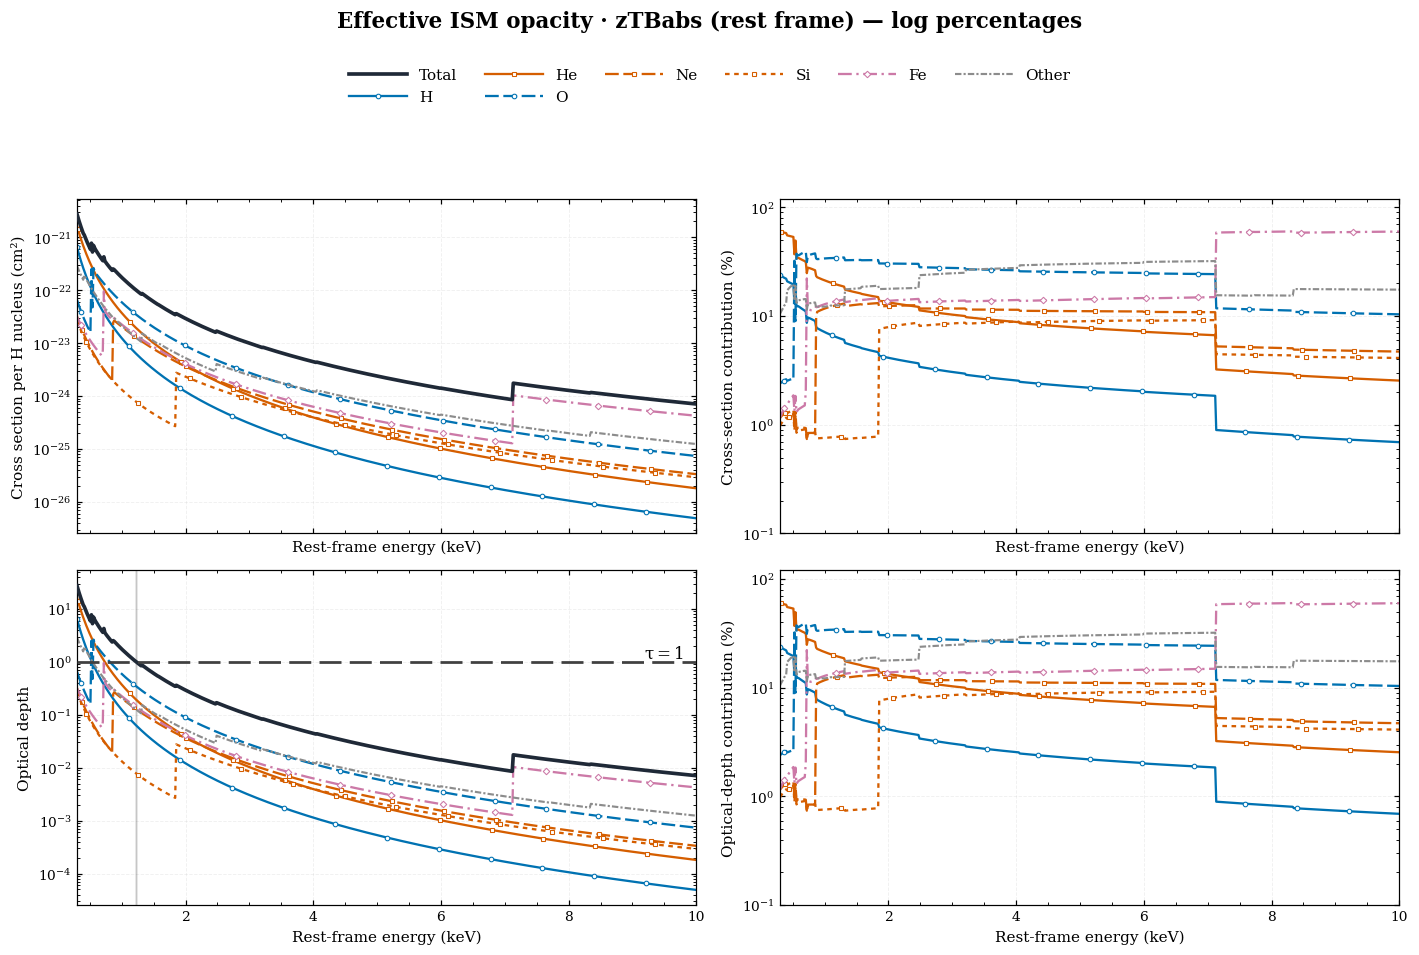

In [3]:
# 静止系能量；避免重复施加红移。
# Rest-frame energies; do not apply a second redshift.
energy = np.linspace(.3, 10, 600)*u.keV
curve = absorption_budget(energy, nh, backend='ztbabs', abundance_table='wilm')
curve.plot(elements=shown, energy_scale='linear', fraction_scale='log')
curve.savefig(output/'ztbabs_wilm')
curve.show()  # 显示图件 / Display the figure.

## 3. 调整元素丰度 / Adjust element abundances

以 wilm 为基准将 O 乘 0.5、Fe 乘 2；吸收模型保持 zTBabs。
Scale O by 0.5 and Fe by 2 relative to wilm, keeping the zTBabs model.

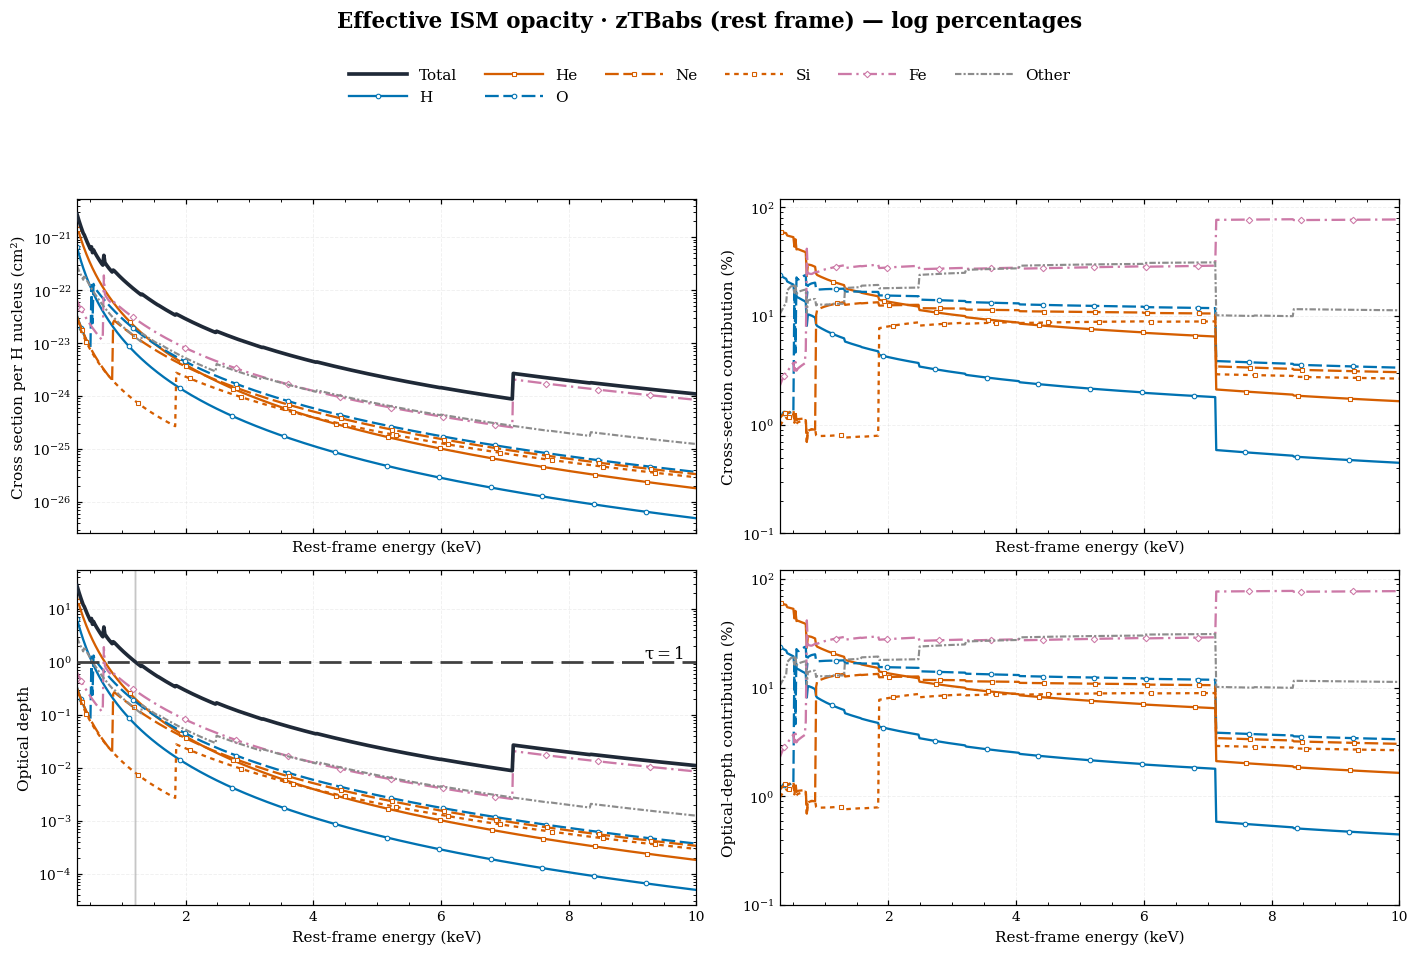

In [4]:
# 元素因子修改数丰度，不切换到原子吸收后端。
# Element factors alter number abundances without switching absorption backends.
modified = absorption_budget(energy, nh, backend='ztbabs', abundance_table='wilm',
                             element_factors={'O': .5, 'Fe': 2.})
modified.plot(elements=shown, energy_scale='linear', fraction_scale='log')
modified.savefig(output/'ztbabs_modified')
modified.show()  # 显示图件 / Display the figure.

## 4. TBabs 对照与有效性 / TBabs comparison and validity

TBabs 的独立元素差分不一定能重现混合物总量。闭合失败时贡献留空，总量保留。
Isolated-element differences need not reproduce mixed TBabs opacity. Failed
closure masks element contributions while preserving native total opacity.
不要把 zTBabs 的分解标为 TBabs。Do not label zTBabs decomposition as TBabs.

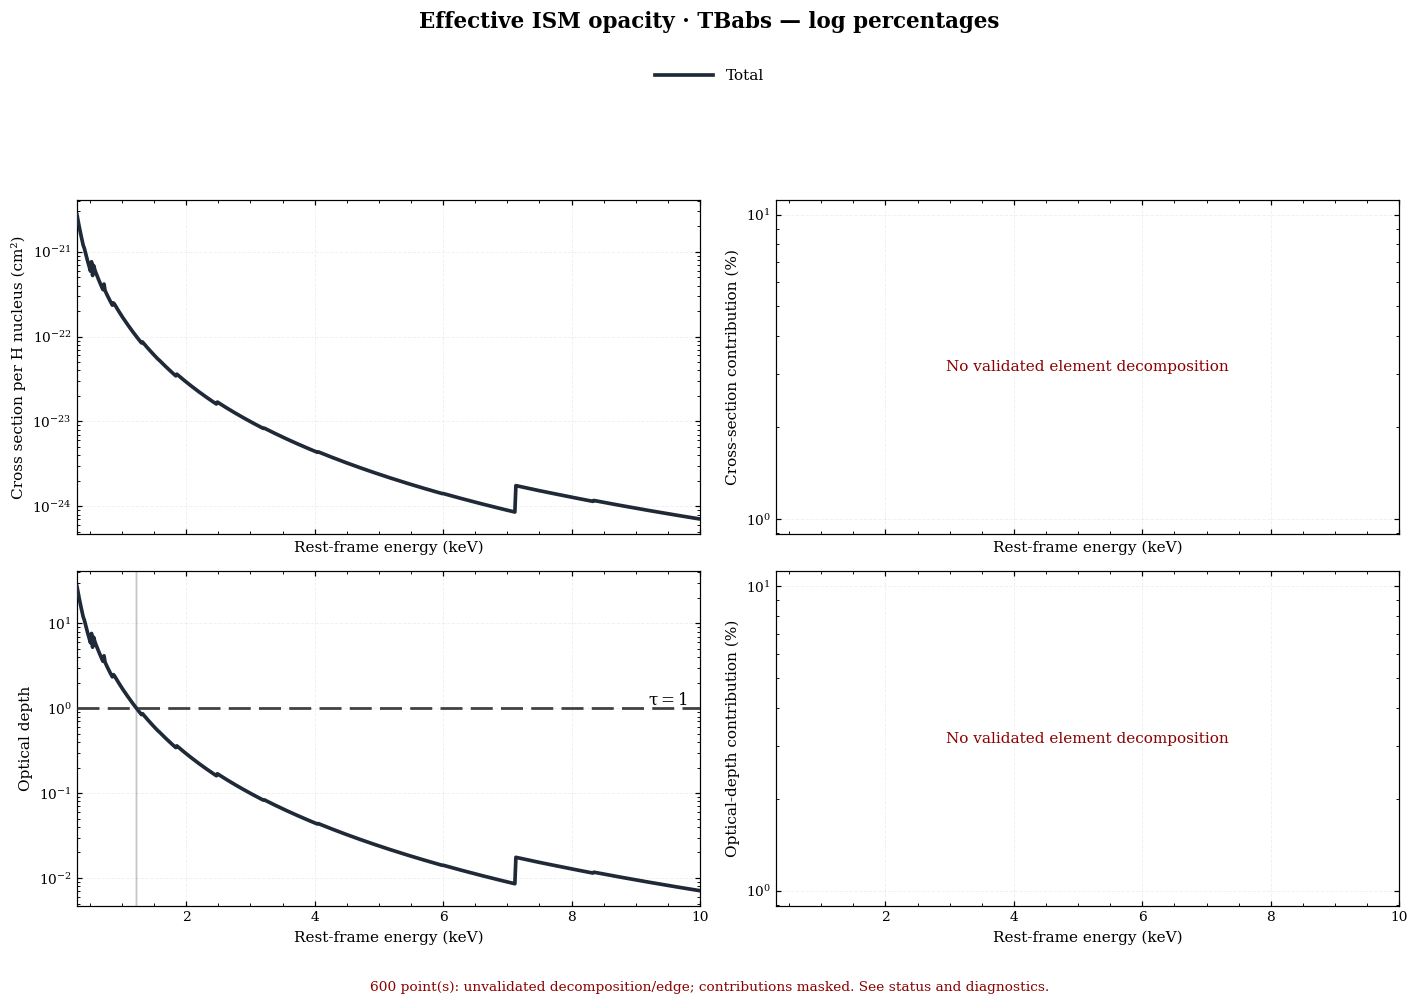

状态 / Status: {np.str_('decomposition_not_closed')}


In [5]:
# 保留原生 TBabs；不能通过更换模型隐藏闭合失败。
# Retain native TBabs rather than hide failed closure by substituting models.
tb = absorption_budget(energy, nh, backend='tbabs', abundance_table='wilm')
tb.plot(elements=shown, energy_scale='linear', fraction_scale='log')
tb.savefig(output/'tbabs_wilm')
tb.show()  # 显示图件 / Display the figure.
print('状态 / Status:', set(tb.totals['status']))

## 5. 导出与重新载入 / Export and reload

JSON 保留单位、状态和模型溯源；重新载入不运行 XSPEC。
JSON preserves units, statuses and provenance; reloading does not run XSPEC.

In [6]:
# 单点表格和完整曲线分别导出。
# Export point tables and the complete curve separately.
points.to_csv(output/'points')
points.to_markdown(output/'points.md')
curve.to_json(output/'curve.json')
restored = AbsorptionBudget.from_json(output/'curve.json')
np.testing.assert_allclose(restored.totals['tau_total'], curve.totals['tau_total'])
print('输出目录 / Output directory:', output)

输出目录 / Output directory: /tmp/opacity_delivery/absorption_tutorial_outputs/20260917T133315054309Z
